# Product Variety Clustering — Elsa.Science

Applied unsupervised clustering to segment product varieties for Elsa.Science, a Swedish EdTech company. Compared K-Means and hierarchical clustering on normalised feature vectors, determined optimal cluster count via the elbow method and silhouette analysis, and profiled each cluster to surface actionable product groupings.

**Stack:** scikit-learn · pandas · NumPy · matplotlib · seaborn

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
%matplotlib inline


In [ ]:
os.chdir('/content/drive/My Drive/Elsa')
print(os.getcwd())

/content/drive/My Drive/Elsa


In [ ]:
samples=pd.read_csv('/content/drive/My Drive/Elsa/norm_df.csv', delimiter=',')

In [ ]:
samples.drop('Unnamed: 0',axis=1, inplace=True)

In [ ]:
samples

,users_nr,hour,numberofsteps,pain,fatigue,weightinkg,numberofcigarettes,year,month,day,Naproxen,Inflectra,Prednisolone,Arava,Mabthera,Plaquenil,Paracetamol,Imraldi,Xeljanz,Methotrexate injection,Folic acid,Humira,Methotrexate pill,Orencia,Ibuprofen,Olumiant,Salazopyrin,happy,calm,expect,act_level,act_dura,nr_pills
0,0,20,7772.0,17.558153,31.837617,72.174041,0.001109,2019,10,31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.759494,0.238397,9.753165,11.696517,0.842123,0
1,0,21,8633.0,13.000000,14.000000,66.000000,0.001109,2019,10,31,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,12.000000,-4.000000,3.000000,7.000000,1.000000,1
2,0,19,4483.0,10.000000,12.000000,66.000000,0.001109,2019,10,30,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,15.000000,-6.000000,11.000000,11.696517,0.842123,2
3,0,20,5363.0,10.000000,12.000000,66.000000,0.001109,2019,10,31,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,11.000000,-12.000000,5.000000,15.000000,1.000000,1
4,0,4,4210.0,10.000000,12.000000,66.000000,0.001109,2019,11,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,11.000000,-12.000000,0.000000,6.000000,0.600000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3180,9,10,10836.0,17.558153,31.837617,72.174041,0.001109,2020,2,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.759494,0.238397,9.753165,11.696517,0.842123,0
3181,9,10,6117.0,17.558153,31.837617,72.174041,0.001109,2020,2,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.759494,0.238397,9.753165,11.696517,0.842123,0
3182,9,10,5668.0,17.558153,31.837617,72.174041,0.001109,2020,2,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.759494,0.238397,9.753165,11.696517,0.842123,0
3183,9,10,7479.0,17.558153,31.837617,72.174041,0.001109,2020,2,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.759494,0.238397,9.753165,11.696517,0.842123,0


In [ ]:
#samples.drop('users_nr', axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
samples=pd.DataFrame(scaler.fit_transform(samples), columns=samples.columns)

In [ ]:
#samples.drop('Unnamed: 0', axis=1, inplace=True)
samples2=samples
print(samples2.shape)
print(samples2.info())

(3185, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3185 entries, 0 to 3184
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   users_nr                 3185 non-null   int64  
 1   hour                     3185 non-null   int64  
 2   numberofsteps            3185 non-null   float64
 3   pain                     3185 non-null   float64
 4   fatigue                  3185 non-null   float64
 5   weightinkg               3185 non-null   float64
 6   numberofcigarettes       3185 non-null   float64
 7   year                     3185 non-null   int64  
 8   month                    3185 non-null   int64  
 9   day                      3185 non-null   int64  
 10   Naproxen                3185 non-null   int64  
 11   Inflectra               3185 non-null   int64  
 12   Prednisolone            3185 non-null   int64  
 13   Arava                   3185 non-null   int64  
 14   Mabthera    

In [ ]:
#Calculate the linkage: mergins
mergings = linkage(samples, method='complete')

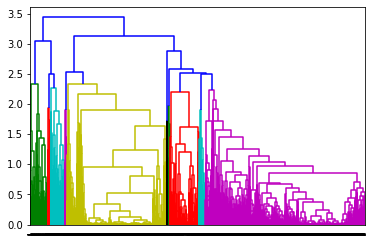

In [ ]:
#Plot the dendrogram, using users as labels
dendrogram1=dendrogram(mergings,
                       labels=varieties,
                       leaf_rotation=90
                       )
plt.show()

In [ ]:
samples.columns

Index(['users_nr', 'hour', 'numberofsteps', 'pain', 'fatigue', 'weightinkg',
       'numberofcigarettes', 'year', 'month', 'day', ' Naproxen', ' Inflectra',
       ' Prednisolone', ' Arava', ' Mabthera', ' Plaquenil', ' Paracetamol',
       ' Imraldi', ' Xeljanz', ' Methotrexate injection', ' Folic acid',
       ' Humira', ' Methotrexate pill', ' Orencia', ' Ibuprofen', ' Olumiant',
       ' Salazopyrin', 'happy', 'calm', 'expect', 'act_level', 'act_dura',
       'nr_pills'],
      dtype='object')

In [ ]:
samples2=samples

In [ ]:
samples2.drop(['hour','numberofcigarettes', 'year', 'month', 'day',  'act_level', 'act_dura'],axis=1, inplace=True)

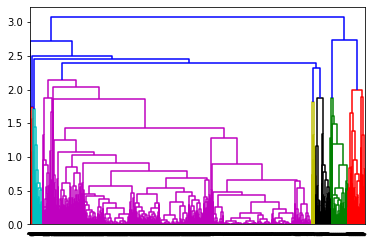

In [ ]:
#Calculate the linkage: mergins
mergings = linkage(samples2, method='complete')
#Plot the dendrogram, using users as labels
dendrogram1=dendrogram(mergings,
                       labels=varieties,
                       leaf_rotation=60
                       )
plt.show()

In [ ]:
samples2.columns

Index(['users_nr', 'numberofsteps', 'pain', 'fatigue', 'weightinkg',
       ' Naproxen', ' Inflectra', ' Prednisolone', ' Arava', ' Mabthera',
       ' Plaquenil', ' Paracetamol', ' Imraldi', ' Xeljanz',
       ' Methotrexate injection', ' Folic acid', ' Humira',
       ' Methotrexate pill', ' Orencia', ' Ibuprofen', ' Olumiant',
       ' Salazopyrin', 'happy', 'calm', 'expect', 'nr_pills'],
      dtype='object')

In [ ]:
samples3=samples2
samples3.drop(['nr_pills'], axis=1, inplace=True)

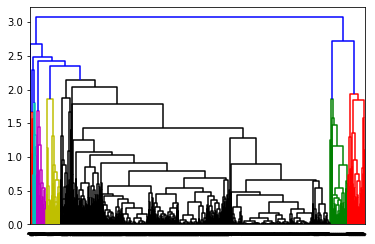

In [ ]:
#Calculate the linkage: mergins
mergings = linkage(samples3, method='complete')
#Plot the dendrogram, using users as labels
dendrogram1=dendrogram(mergings,
                       labels=varieties,
                       leaf_rotation=60
                       )
plt.show()

In [ ]:
samples3.columns

Index(['users_nr', 'numberofsteps', 'pain', 'fatigue', 'weightinkg',
       ' Naproxen', ' Inflectra', ' Prednisolone', ' Arava', ' Mabthera',
       ' Plaquenil', ' Paracetamol', ' Imraldi', ' Xeljanz',
       ' Methotrexate injection', ' Folic acid', ' Humira',
       ' Methotrexate pill', ' Orencia', ' Ibuprofen', ' Olumiant',
       ' Salazopyrin', 'happy', 'calm', 'expect'],
      dtype='object')

## T-SNE CLUSTERING: t-distributed stochastic neighbor embedding
 It maps high-dimensional space into a two or three-dimensional space which can then be visualized.  Similar objects are modeled by nearby points and dissimilar objects are modeled by distant points with high probability.

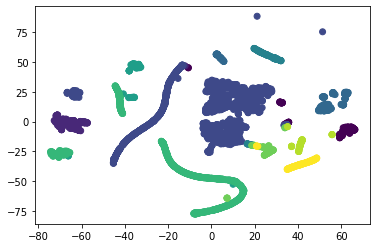

In [ ]:
# Importing Modules
from sklearn import datasets
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Loading dataset
#iris_df = datasets.load_iris()

# Defining Model
model = TSNE(learning_rate=100)

# Fitting Model
transformed = model.fit_transform(samples)

# Plotting 2d t-Sne
x_axis = transformed[:, 0]
y_axis = transformed[:, 1]

plt.scatter(x_axis, y_axis, c=varieties)
plt.show()

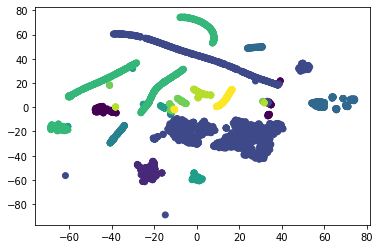

In [ ]:
# Importing Modules
from sklearn import datasets
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Loading dataset
#iris_df = datasets.load_iris()

# Defining Model
model = TSNE(learning_rate=100)

# Fitting Model
transformed = model.fit_transform(samples2)

# Plotting 2d t-Sne
x_axis = transformed[:, 0]
y_axis = transformed[:, 1]

plt.scatter(x_axis, y_axis, c=varieties)
plt.show()

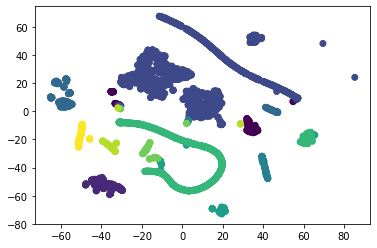

In [ ]:
# Importing Modules
from sklearn import datasets
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Loading dataset
#iris_df = datasets.load_iris()

# Defining Model
model = TSNE(learning_rate=100)

# Fitting Model
transformed = model.fit_transform(samples3)

# Plotting 2d t-Sne
x_axis = transformed[:, 0]
y_axis = transformed[:, 1]

plt.scatter(x_axis, y_axis, c=varieties)
plt.show()

## DBSCAN CLUSTERING
Density-based spatial clustering of applications with noise, or DBSCAN. QUite similar to k-means but it doesn’t require an input for the number of clusters.

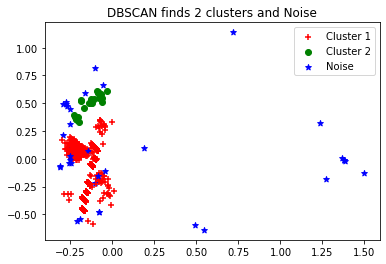

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Declaring Model
dbscan = DBSCAN()

# Fitting
dbscan.fit(samples)

# Transoring Using PCA
pca = PCA(n_components=2).fit(samples3)
pca_2d = pca.transform(samples)

# Plot based on Class
for i in range(0, pca_2d.shape[0]):
    if dbscan.labels_[i] == 0:
        c1 = plt.scatter(pca_2d[i, 0], pca_2d[i, 1], c='r', marker='+')
    elif dbscan.labels_[i] == 1:
        c2 = plt.scatter(pca_2d[i, 0], pca_2d[i, 1], c='g', marker='o')
    elif dbscan.labels_[i] == -1:
        c3 = plt.scatter(pca_2d[i, 0], pca_2d[i, 1], c='b', marker='*')

plt.legend([c1, c2, c3], ['Cluster 1', 'Cluster 2', 'Noise'])
plt.title('DBSCAN finds 2 clusters and Noise')
plt.show()